# Imports and Load Data

In [1]:
%load_ext autoreload
%autoreload 2

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS


from src.data_loader import *
from src.analysis import *
from src.visualization import *
from src.utils import *

from src.visualization import (
    _C_BLUE, _C_ORANGE, _C_EVENT, _C_ZERO, _C_LIGHT, _C_PURPLE, _C_AMBER,
    _FONT_LEGEND, _FONT_LABEL, _FONT_TITLE, _FONT_TICK, _FONT_ANNOT,
    _setup_ax, _finalize, apply_pnas_style,
)

In [4]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
PAPER_DATA_URL = "https://raw.githubusercontent.com/trenault/CommunityNotes/main/database_replication.csv"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"

WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"
NOTES_WITH_TOPICS_PATH = "/accounts/projects/jchayes/commnotes/notes_llm_topic.csv"


max_date = "2023-06-01"

In [5]:
print("--- Loading and Preparing Data ---")
# This DataFrame contains data related to "notes" associated with tweets. It includes unique IDs for notes, authors, and tweets, along with
# timestamps, classifications (e.g., "MISINFORMED_OR_POTENTIALLY_MISLEADING"), and other
# attributes describing the history of the notes
notes_df = pd.read_csv(NOTES_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
notes_df["noteId"]=notes_df["noteId"].astype(int)

# The following is all note ratings published by X
# I only kept the following columns "'noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel'" since we don't use the rest.
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2022-06-01",end_date_str=max_date)

# The following df is the results of the matrix factorzation 
note_df_full, rater_df, status_df, helpfulness_df, aux_df = load_weekly_outputs(WEEKLY_OUTPUTS_PATH,debug=False)

history_df =   pd.read_csv(HISTORY_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
paper_df = pd.read_csv(PAPER_DATA_URL, dtype={'tweet_id': str})

# The following df is notes with corresponding topics. Topics are modelled using LLMs.
notes_df_topic = pd.read_csv("/accounts/projects/jchayes/commnotes/notes_llm_topic.csv")
# notes_df_topic['noteId'] = notes_df_topic['noteId'].astype(int)

--- Loading and Preparing Data ---


/tmp/ipykernel_970118/2586839657.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


Found 16 total rating files. Processing them in chunks to filter by date.


Loading weekly outputs: 100%|██████████| 84/84 [02:36<00:00,  1.86s/it]


note is loaded.
rater is loaded.
status is loaded.
helpfulness is loaded.
aux is loaded.


/tmp/ipykernel_970118/2586839657.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


In [6]:
note_df_full_2025, rater_df_2025, status_df_2025, helpfulness_df_2025, aux_df_2025 = load_weekly_outputs(WEEKLY_OUTPUTS_PATH_2025,debug=False)

Loading weekly outputs: 100%|██████████| 44/44 [00:04<00:00,  8.94it/s]


note is loaded.
rater is loaded.
status is loaded.
key without data status
helpfulness is loaded.
key without data helpfulness
aux is loaded.
key without data aux


In [7]:
rater_df_2025 = rater_df_2025.rename(columns={"internalRaterFactor1": "raterFactor1", "internalRaterIntercept": "raterIntercept"})

# Split Data by Controversial Topic Status

In [8]:
CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

In [9]:
ratings_df_topic = ratings_df.merge(notes_df_topic, how='left', left_on='noteId', right_on='NOTEID')

In [10]:
# remove spaces
ratings_df_topic["TOPIC"] = (
    ratings_df_topic["TOPIC"]
      .astype(str)
      .str.strip()          # remove leading/trailing whitespace
      .str.replace(r"\s+", "", regex=True)   # remove ALL whitespace (spaces, tabs, etc.)
)

In [11]:
ratings_df_topic['week_dt'] = pd.to_datetime(ratings_df_topic['createdAtMillis'], unit='ms').dt.to_period('W').dt.start_time

In [12]:
# assign phase based on month_str
ratings_df_topic['month_str'] = ratings_df_topic['week_dt'].dt.strftime('%Y-%m')
ratings_df_topic['phase'] = ratings_df_topic['month_str'].apply(assign_phase)

In [13]:
ratings_df_topic.shape

(408785, 11)

In [14]:
ratings_contr = ratings_df_topic[ratings_df_topic['TOPIC'].isin(CONTROVERSIAL_TOPICS)]
ratings_non_contr = ratings_df_topic[ratings_df_topic['TOPIC'].isin(NON_CONTROVERSIAL_TOPICS)]

In [15]:
ratings_contr.drop(columns=['NOTEID', 'SUMMARY', 'TOPIC', 'LLAMA4', 'week_dt', 'month_str', 'phase'], errors="ignore").to_csv(
    "/scratch/users/commnotes/communitynotes/sourcecode/ratings_controversial.tsv",
    sep="\t",
    index=False
)

ratings_non_contr.drop(columns=['NOTEID', 'SUMMARY', 'TOPIC', 'LLAMA4', 'week_dt', 'month_str', 'phase'], errors="ignore").to_csv(
    "/scratch/users/commnotes/communitynotes/sourcecode/ratings_non_controversial.tsv",
    sep="\t",
    index=False
)

# Read in the post-processed data

In [16]:
ratings_contr = pd.read_csv("/scratch/users/commnotes/communitynotes/sourcecode/ratings_controversial.tsv", sep="\t")
ratings_non_contr = pd.read_csv("/scratch/users/commnotes/communitynotes/sourcecode/ratings_non_controversial.tsv", sep="\t")

# Data Analysis Final

In [17]:
# start_date = pd.to_datetime("2022-08-01")
partial_rollout_date = pd.to_datetime("2022-10-01")
full_rollout_date = pd.to_datetime("2023-01-01")

window = 12

In [18]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

# identify users who were present before initial rollout and who had a factor
old_user_ratings_df = ratings_df[ratings_df['createdAtDate'] < partial_rollout_date]
old_user_ids = old_user_ratings_df['raterParticipantId'].unique()

# get their factors before the partial rollout
old_user_rater_df_2025 = rater_df_2025[(rater_df_2025['week_dt'] < partial_rollout_date) & (rater_df_2025['raterParticipantId'].isin(old_user_ids))] 
old_user_rater_df_full_2025 = rater_df_2025[(rater_df_2025['raterParticipantId'].isin(old_user_ids))] 

In [19]:
# compute factors for old users before the full rollout_date
test = (
    old_user_rater_df_full_2025
    .sort_values(['raterParticipantId', 'week_dt'])
    .groupby('raterParticipantId')
    .agg(
        firstFactor=('raterFactor1', 'first'),
        firstFactorDate=('week_dt', 'first'),
        meanFactor=('raterFactor1', 'mean'),
        lastFactor=('raterFactor1', 'last'),
        lastFactorDate=('week_dt', 'last')
    )
    .reset_index()
)
test['factorShift'] = test['lastFactor'] - test['firstFactor']

Text(0.5, 1.0, 'Histogram of Factor Shift for Users Active Before Initial Rollout')

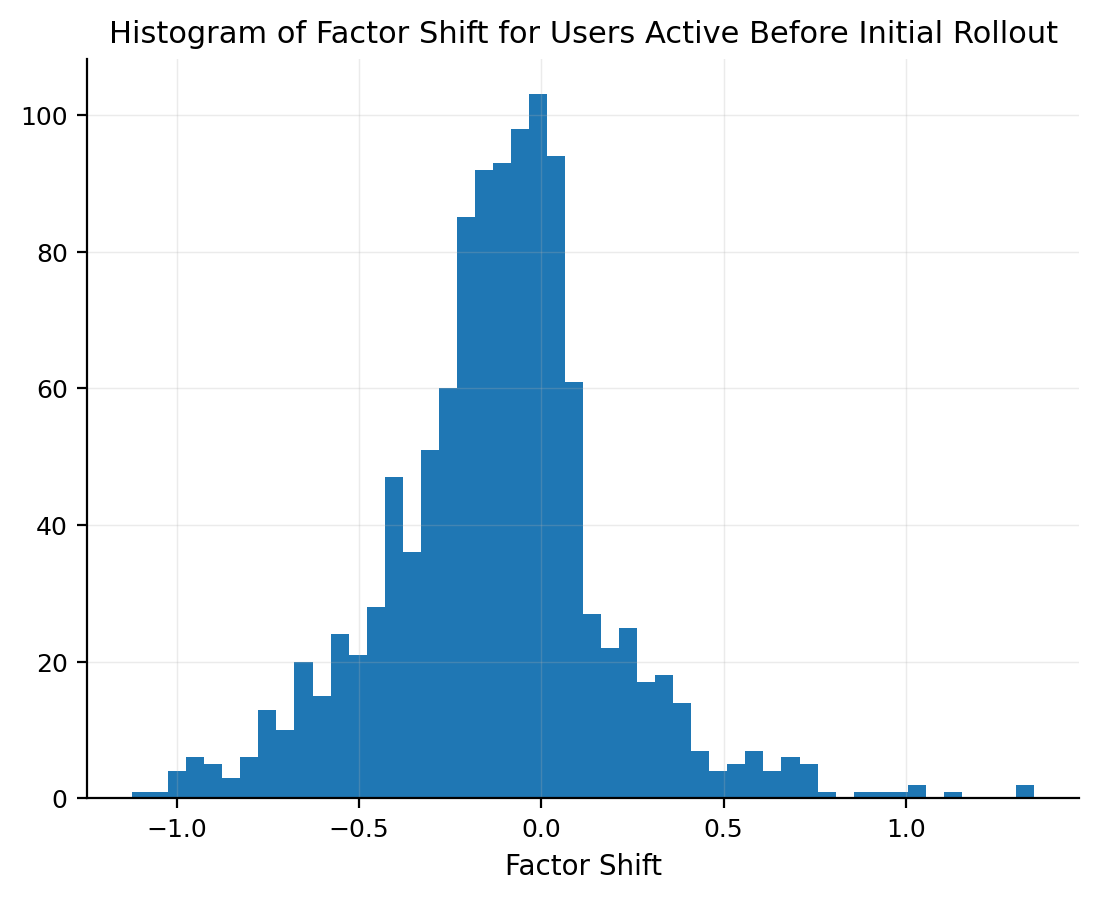

In [20]:
plt.hist(test['factorShift'], bins=50)
plt.xlabel('Factor Shift')
plt.title('Histogram of Factor Shift for Users Active Before Initial Rollout')
# plt.savefig("factor_shift_histogram.png")
# plt.close()


In [21]:
np.mean(test['factorShift']), np.median(test['factorShift']), np.std(test['factorShift'])

(np.float64(-0.12120070299553357),
 np.float64(-0.10679914999999995),
 np.float64(0.31023132440710854))

In [22]:
# compute factors for old users before the full rollout_date
old_user_factors = pd.DataFrame(columns=[
    'raterParticipantId', 'firstFactor', 'firstFactorDate',
    'lastFactor', 'lastFactorDate', 'meanFactor'
])

old_user_factors = (
    old_user_rater_df_2025
    .sort_values(['raterParticipantId', 'week_dt'])
    .groupby('raterParticipantId')
    .agg(
        firstFactor=('raterFactor1', 'first'),
        firstFactorDate=('week_dt', 'first'),
        meanFactor=('raterFactor1', 'mean'),
        lastFactor=('raterFactor1', 'last'),
        lastFactorDate=('week_dt', 'last')
    )
    .reset_index()
)
old_user_factors['factorShift'] = old_user_factors['lastFactor'] - old_user_factors['firstFactor']

In [23]:
# Print total number of users, number with lastFactor > 0, and number with lastFactor < 0
total_users = old_user_factors.shape[0]
num_pos = (old_user_factors['lastFactor'] > 0).sum()
num_neg = (old_user_factors['lastFactor'] < 0).sum()
print(f"Total users: {total_users}")
print(f"Users with lastFactor > 0: {num_pos}")
print(f"Users with lastFactor < 0: {num_neg}")

num_null = old_user_factors['lastFactor'].isna().sum()
print(f"Users with lastFactor NaN: {num_null}")

Total users: 1052
Users with lastFactor > 0: 354
Users with lastFactor < 0: 698
Users with lastFactor NaN: 0


In [24]:
old_user_factors['lastFactor'].describe()

count    1052.000000
mean       -0.145597
std         0.433663
min        -0.992660
25%        -0.488362
50%        -0.159485
75%         0.122295
max         1.099046
Name: lastFactor, dtype: float64

In [25]:
# process ratings data
ratings_df_with_topic = ratings_df.copy().merge(notes_df_topic, how='left', left_on='noteId', right_on='NOTEID')


# add controversy indicator
CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
    'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

ratings_df_with_topic['TOPIC'] = ratings_df_with_topic["TOPIC"].astype(str).str.strip().str.replace(r"\s+", "", regex=True)
ratings_df_with_topic['is_controversial'] = ratings_df_with_topic['TOPIC'].apply(
    lambda x: 1 if x in CONTROVERSIAL_TOPICS else (0 if x in NON_CONTROVERSIAL_TOPICS else np.nan)
)

ratings_df_with_topic.dropna(subset=['is_controversial'], inplace=True)
ratings_df_with_topic = ratings_df_with_topic.merge(old_user_factors, on='raterParticipantId', how='left')

# this is a dataframe with ratings only from users that were active before rating impact was initially rolled out
old_users = old_user_factors['raterParticipantId'].unique()
old_user_ratings_df = ratings_df_with_topic[ratings_df_with_topic['raterParticipantId'].isin(old_users)] 

old_user_ratings_df['week_dt'] = pd.to_datetime(old_user_ratings_df['createdAtDate']).dt.to_period('W').dt.start_time


/tmp/ipykernel_970118/924506874.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [26]:
# out is a dataframe with columns: user, week_dt, n_ratings, n_controversial, raterFactor1, prop_controversial
out = (
    old_user_ratings_df
    .groupby(["raterParticipantId", "week_dt"], as_index=False)
    .agg(
        n_ratings=("noteId", "size"),
        n_controversial=("is_controversial", "sum"),  # bool/0-1
        raterFactor=("lastFactor", "first"),
    )
    .rename(columns={"raterParticipantId": "user"})
)
out = out[out['n_ratings'] >= 0]
out['prop_controversial'] = out['n_controversial'] / out['n_ratings']
out['log_n_ratings'] = np.log1p(out['n_ratings']+1)
out['log_n_controversial'] = np.log1p(out['n_controversial']+1)
# out['minority'] = (out['raterFactor'] > 0).astype(int)

In [27]:
# out['minority'] = np.where(out['raterFactor'] > np.quantile(out['raterFactor'], 0.75), 1, 0)
out['minority'] = (out['raterFactor'] > 0.1).astype(int)

In [28]:
out_min = out[out['minority'] == 1]

In [29]:
out_min['raterFactor'].describe()

count    3135.000000
mean        0.554444
std         0.299592
min         0.101433
25%         0.264023
50%         0.547452
75%         0.850174
max         1.099046
Name: raterFactor, dtype: float64

(array([461., 499., 283., 163., 303., 169., 336., 389., 404., 128.]),
 array([0.10143288, 0.20119419, 0.3009555 , 0.40071681, 0.50047812,
        0.60023944, 0.70000075, 0.79976206, 0.89952338, 0.99928469,
        1.099046  ]),
 <BarContainer object of 10 artists>)

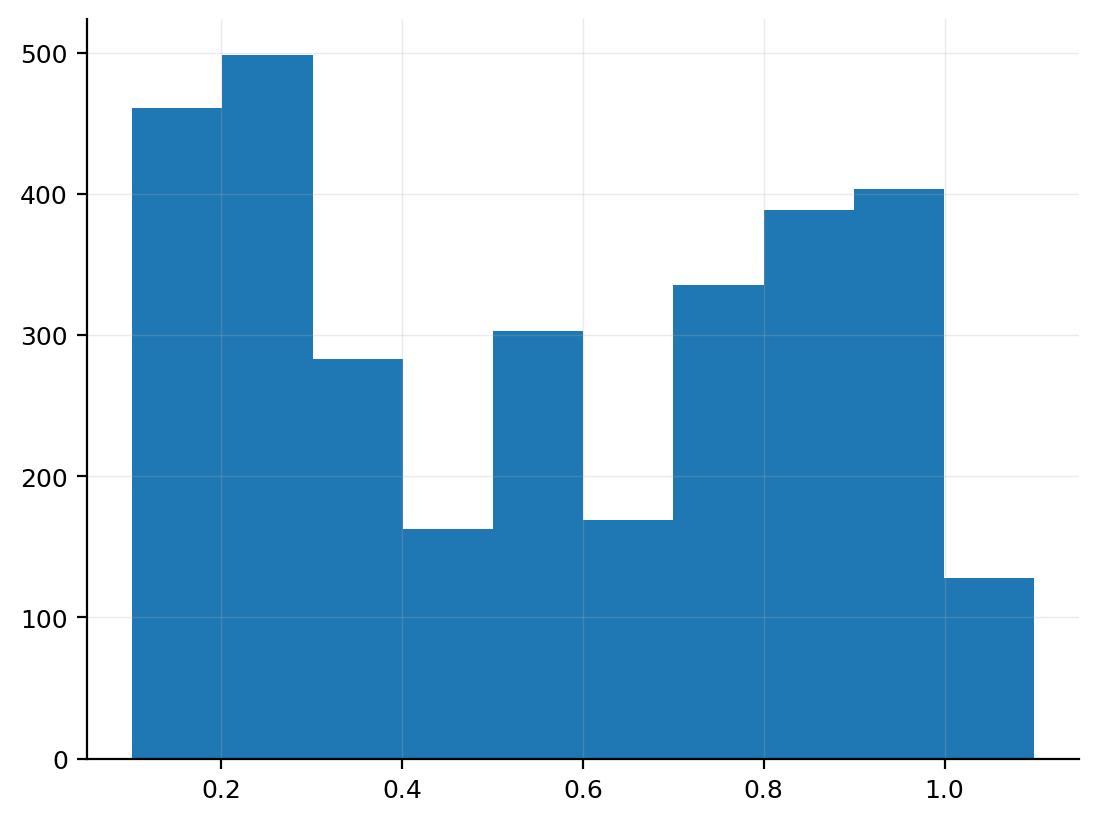

In [30]:
plt.hist(out_min['raterFactor'])

In [31]:
# function to run DiD
def run_did(df, outcome, minority_col, cutoff_date, window_weeks=12):
    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    cutoff = pd.to_datetime(cutoff_date)

    # window
    lo = cutoff - pd.Timedelta(weeks=window_weeks)
    hi = cutoff + pd.Timedelta(weeks=window_weeks)
    d = d[(d["week_dt"] >= lo) & (d["week_dt"] < hi)].copy()

    # drop unknown treatment assignment
    d = d[d[minority_col].notna()].copy()

    # # Post + keep only users active both pre and post (within window)
    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    # pre_users  = set(d.loc[d["Post"] == 0, "user"])
    # post_users = set(d.loc[d["Post"] == 1, "user"])
    # keep_users = pre_users & post_users
    # d = d[d["user"].isin(keep_users)].copy()

    # interaction
    d["treat"] = d[minority_col] * d["Post"]

    panel = d.set_index(["user", "week_dt"]).sort_index()
    res = PanelOLS.from_formula(
        f"{outcome} ~ 1 + treat + EntityEffects + TimeEffects",
        data=panel,
        drop_absorbed=True
    ).fit(cov_type="clustered", cluster_entity=True)

    return res


In [32]:
# DiD prop, old users, initial rollout
res1 = run_did(out, outcome="prop_controversial", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res1.summary)

# DiD num_controversial, old users, initial rollout
res2 = run_did(out, outcome="log_n_controversial", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res2.summary)

# DiD num, old users, initial rollout
res3 = run_did(out, outcome="log_n_ratings", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res3.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:     prop_controversial   R-squared:                        0.0017
Estimator:                   PanelOLS   R-squared (Between):             -0.0315
No. Observations:                4779   R-squared (Within):               0.0081
Date:                Thu, May 28 2026   R-squared (Overall):              0.0011
Time:                        22:10:30   Log-likelihood                   -1405.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.3811
Entities:                         955   P-value                           0.0116
Avg Obs:                       5.0042   Distribution:                  F(1,3800)
Min Obs:                       1.0000                                           
Max Obs:                       24.000   F-statistic (robust):             4.8077
                            

# Plot the DiDs

In [39]:
def plot_did_means(
    df,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    title="DiD means: minority vs majority",
    save_path=None,
):
    cutoff = pd.to_datetime(cutoff_date)

    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    d = d[d[minority_col].notna()].copy()

    d = d[
        (d["week_dt"] >= cutoff - pd.Timedelta(weeks=window_weeks)) &
        (d["week_dt"] <= cutoff + pd.Timedelta(weeks=window_weeks))
    ].copy()

    d["period"] = np.where(d["week_dt"] >= cutoff, "Post", "Pre")
    d["group"] = np.where(d[minority_col].eq(1), "Minority", "Majority")

    means = (
        d.groupby(["group", "period"], as_index=False)[outcome]
        .mean()
    )

    order = ["Pre", "Post"]
    group_order = ["Majority", "Minority"]
    colors = {
        "Majority": _C_BLUE,
        "Minority": _C_ORANGE,
    }

    apply_pnas_style()
    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    for group in group_order:
        sub = means[means["group"].eq(group)].copy()
        sub["period"] = pd.Categorical(sub["period"], categories=order, ordered=True)
        sub = sub.sort_values("period")

        ax.plot(
            sub["period"],
            sub[outcome],
            marker="o",
            markersize=5,
            linewidth=2.2,
            color=colors[group],
            label=group,
            zorder=3,
        )

    ax.axvline(0.5, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=1)

    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="best")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Period",
        ylabel="Mean share of ratings on controversial topics",
        title=title,
        save_path=save_path,
    )

    return means

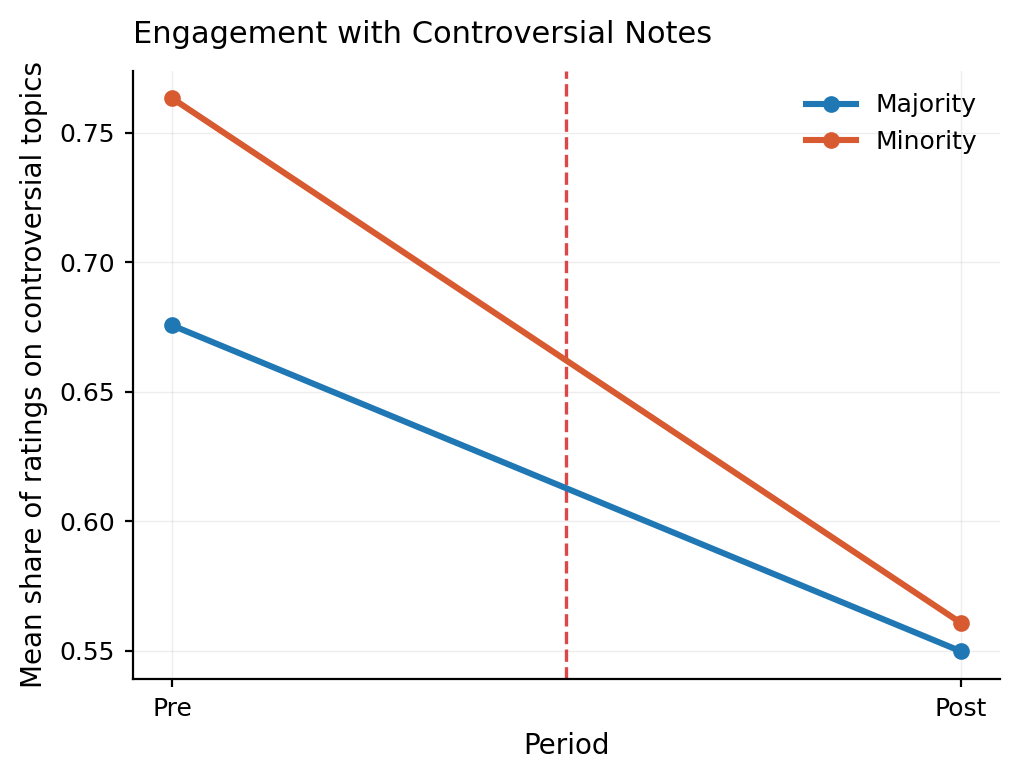

In [41]:
did_means = plot_did_means(
    out,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    title="Engagement with Controversial Notes",
    save_path="final_code/figures-pnas/did_means_prop_controversial_initial_rollout.png",
)

In [56]:
def plot_did_points_and_fit(
    df,
    res,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    title="DiD: controversial engagement",
    save_path=None,
):
    cutoff = pd.to_datetime(cutoff_date)

    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    d = d[d[minority_col].notna()].copy()

    d = d[
        (d["week_dt"] >= cutoff - pd.Timedelta(weeks=window_weeks)) &
        (d["week_dt"] <= cutoff + pd.Timedelta(weeks=window_weeks))
    ].copy()

    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    d["group"] = np.where(d[minority_col].eq(1), "Minority", "Majority")
    d["rel_week"] = ((d["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    weekly = (
        d.groupby(["rel_week", "group"], as_index=False)[outcome]
        .mean()
    )

    did_means = (
        d.groupby(["group", "Post"], as_index=False)[outcome]
        .mean()
    )

    colors = {
        "Majority": _C_BLUE,
        "Minority": _C_ORANGE,
    }

    apply_pnas_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for group in ["Majority", "Minority"]:
        sub = weekly[weekly["group"].eq(group)]

        ax.scatter(
            sub["rel_week"],
            sub[outcome],
            color=colors[group],
            alpha=0.45,
            s=18,
            linewidths=0,
            label=f"{group} weekly mean",
            zorder=2,
        )

        gmeans = did_means[did_means["group"].eq(group)]

        pre_mean = gmeans.loc[gmeans["Post"].eq(0), outcome].iloc[0]
        post_mean = gmeans.loc[gmeans["Post"].eq(1), outcome].iloc[0]

        ax.hlines(
            pre_mean,
            xmin=-window_weeks,
            xmax=-0.05,
            color=colors[group],
            linewidth=2.4,
            zorder=4,
        )

        ax.hlines(
            post_mean,
            xmin=0.05,
            xmax=window_weeks,
            color=colors[group],
            linewidth=2.4,
            zorder=4,
        )

        ax.plot(
            [-0.05, 0.05],
            [pre_mean, post_mean],
            color=colors[group],
            linewidth=1.2,
            linestyle="--",
            alpha=0.8,
            zorder=3,
        )

    did_coef = res.params["treat"]
    did_pval = res.pvalues["treat"]

    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(
        0.8,
        0.97,
        "Rating Impact\nrollout",
        color=_C_EVENT,
        fontsize=_FONT_ANNOT,
        va="top",
        ha="left",
        transform=ax.get_xaxis_transform(),
    )

    ax.text(
        0.02,
        0.05,
        f"DiD estimate: {did_coef:.3f}\np = {did_pval:.3f}",
        transform=ax.transAxes,
        fontsize=_FONT_ANNOT,
        ha="left",
        va="bottom",
    )

    legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=_C_BLUE,
        markeredgecolor=_C_BLUE,
        markersize=6,
        label="Majority weekly mean",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=_C_ORANGE,
        markeredgecolor=_C_ORANGE,
        markersize=6,
        label="Minority weekly mean",
    ),
]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=_FONT_LEGEND,
        loc="upper right",
    )

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks relative to rollout",
        ylabel="Mean share of ratings on controversial topics",
        title=title,
        save_path=save_path,
    )

    return weekly, did_means

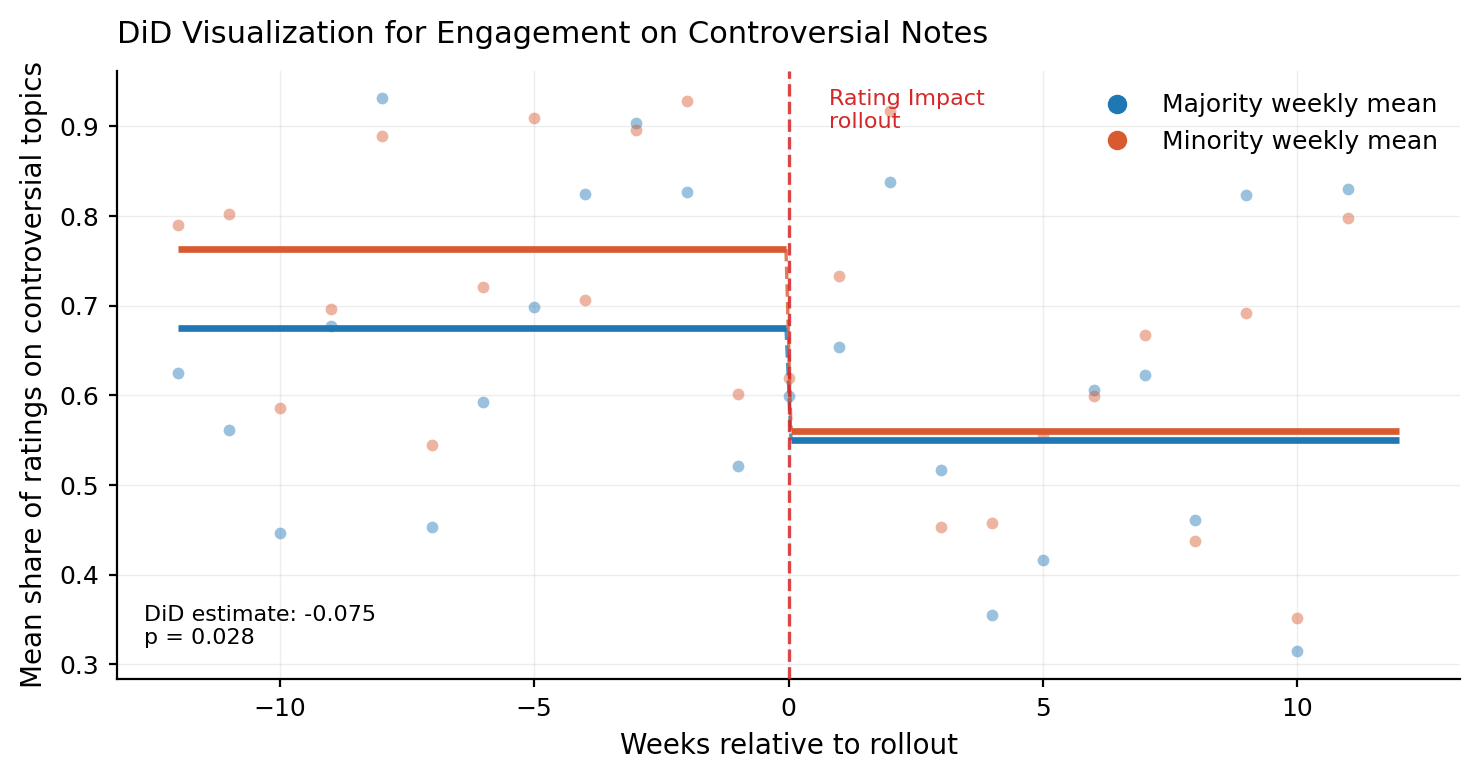

In [57]:
weekly, did_means = plot_did_points_and_fit(
    out,
    res1,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    title="DiD Visualization for Engagement on Controversial Notes",
    save_path="final_code/figures-pnas/did_prop_controversial_points_fit.png",
)

In [53]:
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess

def plot_did_smoothed_trends(
    df,
    res,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    frac_lowess=0.35,
    title="DiD: controversial engagement",
    save_path=None,
):
    cutoff = pd.to_datetime(cutoff_date)

    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    d = d[d[minority_col].notna()].copy()

    d = d[
        (d["week_dt"] >= cutoff - pd.Timedelta(weeks=window_weeks)) &
        (d["week_dt"] < cutoff + pd.Timedelta(weeks=window_weeks))
    ].copy()

    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    d["group"] = np.where(d[minority_col].eq(1), "Minority", "Majority")
    d["rel_week"] = ((d["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    weekly = (
        d.groupby(["rel_week", "group"], as_index=False)[outcome]
        .mean()
    )

    did_means = (
        d.groupby(["group", "Post"], as_index=False)[outcome]
        .mean()
    )

    colors = {
        "Majority": _C_BLUE,
        "Minority": _C_ORANGE,
    }

    apply_pnas_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for group in ["Majority", "Minority"]:
        sub = weekly[weekly["group"].eq(group)].sort_values("rel_week")
        x = sub["rel_week"].to_numpy(dtype=float)
        y = sub[outcome].to_numpy(dtype=float)

        ax.scatter(
            x, y,
            color=colors[group],
            alpha=0.35,
            s=18,
            linewidths=0,
            zorder=2,
        )

        if len(sub) >= 4:
            sm = _lowess(y, x, frac=frac_lowess, return_sorted=True)
            ax.plot(
                sm[:, 0], sm[:, 1],
                color=colors[group],
                linewidth=2.4,
                label=group,
                zorder=4,
            )

        gmeans = did_means[did_means["group"].eq(group)]

        pre_mean = gmeans.loc[gmeans["Post"].eq(0), outcome].iloc[0]
        post_mean = gmeans.loc[gmeans["Post"].eq(1), outcome].iloc[0]

        ax.hlines(
            pre_mean,
            xmin=-window_weeks,
            xmax=-0.15,
            color=colors[group],
            linewidth=1.2,
            linestyle="--",
            alpha=0.75,
            zorder=3,
        )

        ax.hlines(
            post_mean,
            xmin=0.15,
            xmax=window_weeks,
            color=colors[group],
            linewidth=1.2,
            linestyle="--",
            alpha=0.75,
            zorder=3,
        )

    did_coef = res.params["treat"]
    did_pval = res.pvalues["treat"]

    ax.axvline(
        0,
        color=_C_EVENT,
        linewidth=1.2,
        linestyle="--",
        alpha=0.85,
        zorder=5,
    )

    ax.text(
        0.8,
        0.97,
        "Rating Impact\nrollout",
        color=_C_EVENT,
        fontsize=_FONT_ANNOT,
        va="top",
        ha="left",
        transform=ax.get_xaxis_transform(),
    )

    ax.text(
        0.02,
        0.05,
        f"DiD estimate: {did_coef:.3f}\np = {did_pval:.3f}",
        transform=ax.transAxes,
        fontsize=_FONT_ANNOT,
        ha="left",
        va="bottom",
    )

    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks relative to rollout",
        ylabel="Mean proportion of ratings on controversial topics",
        title=title,
        save_path=save_path,
    )

    return weekly, did_means

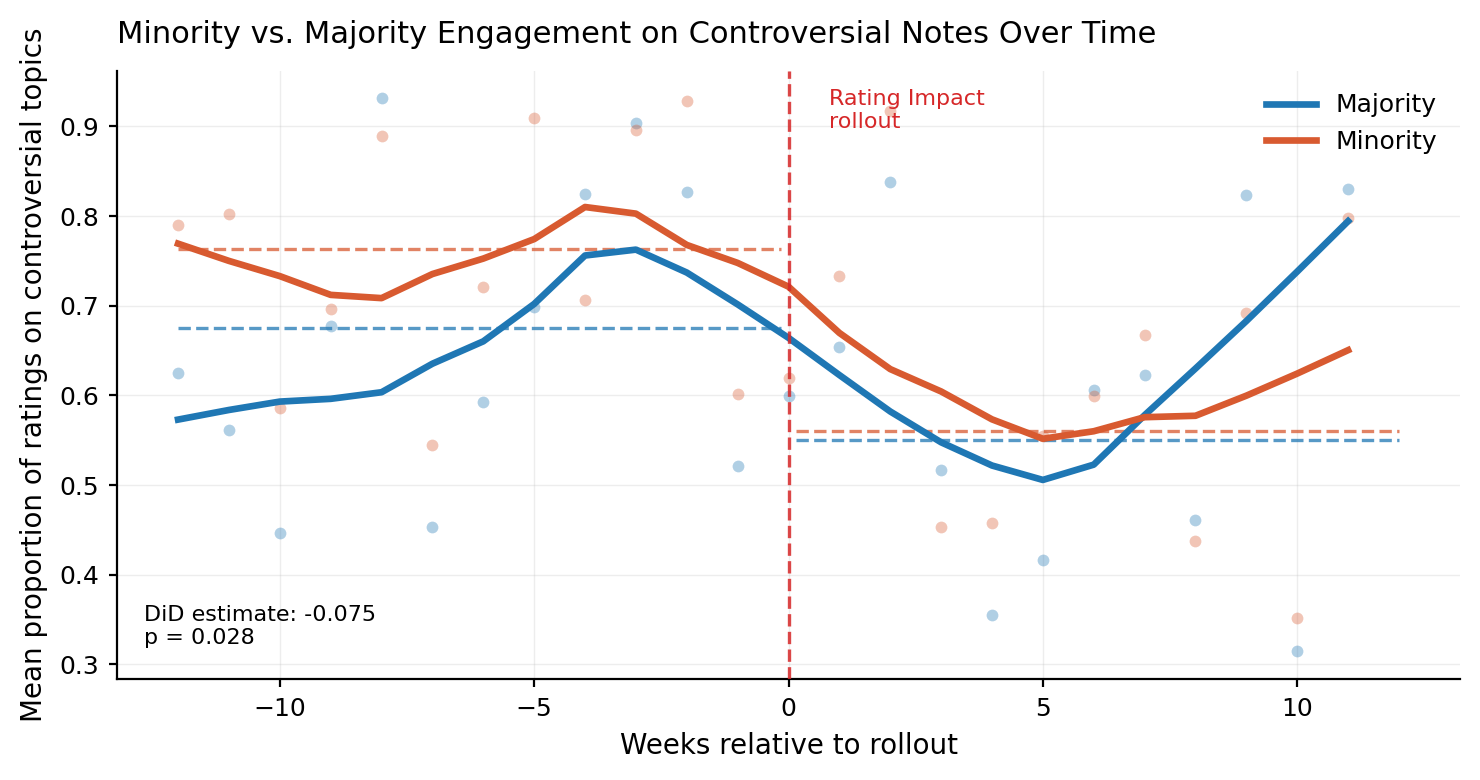

In [55]:
weekly, did_means = plot_did_smoothed_trends(
    out,
    res1,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    title="Minority vs. Majority Engagement on Controversial Notes Over Time",
    save_path="final_code/figures-pnas/did_smoothed_prop_controversial.png",
)

# Data Analysis

In [8]:
rater_df[rater_df['week_dt'] < pd.Timestamp("2022-10-01")]['raterParticipantId'].nunique()

51

In [9]:
rater_df_2025[rater_df_2025['week_dt'] < pd.Timestamp("2022-10-01")]['raterParticipantId'].nunique()

1318

In [11]:
# start_date = pd.to_datetime("2022-08-01")
partial_rollout_date = pd.to_datetime("2022-10-01")
full_rollout_date = pd.to_datetime("2023-01-01")

window = 12

In [84]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')
old_user_ratings_df = ratings_df[ratings_df['createdAtDate'] < partial_rollout_date]
old_user_ids = old_user_ratings_df['raterParticipantId'].unique()
old_user_rater_df_2025 = rater_df_2025[(rater_df_2025['week_dt'] < full_rollout_date) & (rater_df_2025['raterParticipantId'].isin(old_user_ids))] 

In [85]:
old_user_factors = pd.DataFrame(columns=[
    'raterParticipantId', 'firstFactor', 'firstFactorDate',
    'lastFactor', 'lastFactorDate', 'meanFactor'
])

old_user_factors = (
    old_user_rater_df_2025
    .sort_values(['raterParticipantId', 'week_dt'])
    .groupby('raterParticipantId')
    .agg(
        firstFactor=('raterFactor1', 'first'),
        firstFactorDate=('week_dt', 'first'),
        meanFactor=('raterFactor1', 'mean'),
        lastFactor=('raterFactor1', 'last'),
        lastFactorDate=('week_dt', 'last')
    )
    .reset_index()
)


In [86]:
old_user_factors.shape

(1140, 6)

In [87]:
def run_did(df, outcome, minority_col, cutoff_date, window_weeks=12):
    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    cutoff = pd.to_datetime(cutoff_date)

    # window
    lo = cutoff - pd.Timedelta(weeks=window_weeks)
    hi = cutoff + pd.Timedelta(weeks=window_weeks)
    d = d[(d["week_dt"] >= lo) & (d["week_dt"] < hi)].copy()

    # drop unknown treatment assignment
    d = d[d[minority_col].notna()].copy()

    # Post + keep only users active both pre and post (within window)
    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    pre_users  = set(d.loc[d["Post"] == 0, "user"])
    post_users = set(d.loc[d["Post"] == 1, "user"])
    keep_users = pre_users & post_users
    d = d[d["user"].isin(keep_users)].copy()

    # interaction
    d["treat"] = d[minority_col] * d["Post"]

    panel = d.set_index(["user", "week_dt"]).sort_index()
    res = PanelOLS.from_formula(
        f"{outcome} ~ 1 + treat + EntityEffects + TimeEffects",
        data=panel,
        drop_absorbed=True
    ).fit(cov_type="clustered", cluster_entity=True)

    return res


In [88]:
# merge topic dataframe
ratings_df_with_topic = ratings_df.copy().merge(notes_df_topic, how='left', left_on='noteId', right_on='NOTEID')

# merge rater factors
# ratings_df_with_topic = prepare_rater_factors_over_time_weekly(
#     ratings_df_with_topic,
#     rater_df_2025,
#     rater_factor_col='internalRaterFactor1'
# )

In [89]:
ratings_df_with_topic.shape

(408785, 9)

In [90]:
# add controversy indicator
CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
    'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

ratings_df_with_topic['TOPIC'] = ratings_df_with_topic["TOPIC"].astype(str).str.strip().str.replace(r"\s+", "", regex=True)
ratings_df_with_topic['is_controversial'] = ratings_df_with_topic['TOPIC'].apply(
    lambda x: 1 if x in CONTROVERSIAL_TOPICS else (0 if x in NON_CONTROVERSIAL_TOPICS else np.nan)
)

In [91]:
ratings_df_with_topic.dropna(subset=['is_controversial'], inplace=True)

In [92]:
ratings_df_with_topic.shape
ratings_df_with_topic[ratings_df_with_topic['createdAtDate'] < partial_rollout_date]['raterParticipantId'].nunique()

976

In [93]:
ratings_df_with_topic = ratings_df_with_topic.merge(old_user_factors, on='raterParticipantId', how='left')

# this is a dataframe with ratings only from users that were active before rating impact was initially rolled out
old_users = old_user_factors['raterParticipantId'].unique()
old_user_ratings_df = ratings_df_with_topic[ratings_df_with_topic['raterParticipantId'].isin(old_users)] 

In [94]:
old_user_ratings_df.head()

,noteId,raterParticipantId,createdAtMillis,helpfulnessLevel,createdAtDate,NOTEID,SUMMARY,TOPIC,LLAMA4,is_controversial,firstFactor,firstFactorDate,meanFactor,lastFactor,lastFactorDate
864,1604192176816136192,F5A7E3FE8AED2C1B3A5F2BEB646D6F7DB11951E928E633...,1671384127445,HELPFUL,2022-12-18 17:22:07.445,1.604192e+18,Transport Mode is only intended to allow for w...,TechCompanies,Tech Companies,0.0,0.309373,2022-08-01,0.311513,0.376108,2022-12-26
865,1606132077124001792,F5A7E3FE8AED2C1B3A5F2BEB646D6F7DB11951E928E633...,1672202222432,HELPFUL,2022-12-28 04:37:02.432,1.606132e+18,Dan O'Dowd owns a competing company writing se...,ArtificialIntelligence,Artificial Intelligence,0.0,0.309373,2022-08-01,0.311513,0.376108,2022-12-26
866,1652153125480923137,F5A7E3FE8AED2C1B3A5F2BEB646D6F7DB11951E928E633...,1682791017548,HELPFUL,2023-04-29 17:56:57.548,1.652153e+18,Community Notes doesn't work by majority rules...,TechCompanies,Artificial Intelligence,0.0,0.309373,2022-08-01,0.311513,0.376108,2022-12-26
867,1653145624626298884,F5A7E3FE8AED2C1B3A5F2BEB646D6F7DB11951E928E633...,1683071345073,HELPFUL,2023-05-02 23:49:05.073,1.653146e+18,The number of migrants crossing the US souther...,USPolitics,US Politics,1.0,0.309373,2022-08-01,0.311513,0.376108,2022-12-26
868,1655299368419827712,F5A7E3FE8AED2C1B3A5F2BEB646D6F7DB11951E928E633...,1683508017666,HELPFUL,2023-05-08 01:06:57.666,1.655299e+18,Desalination is in fact very cheap. $0.50 per...,ClimateEnvironment,NaN,0.0,0.309373,2022-08-01,0.311513,0.376108,2022-12-26


In [95]:
old_user_ratings_df['week_dt'] = pd.to_datetime(old_user_ratings_df['createdAtDate']).dt.to_period('W').dt.start_time

/tmp/ipykernel_1274503/2569557771.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [96]:
# out is a dataframe with columns: user, week_dt, n_ratings, n_controversial, raterFactor1, prop_controversial
out = (
    old_user_ratings_df
    .groupby(["raterParticipantId", "week_dt"], as_index=False)
    .agg(
        n_ratings=("noteId", "size"),
        n_controversial=("is_controversial", "sum"),  # bool/0-1
        raterFactor=("lastFactor", "first"),
    )
    .rename(columns={"raterParticipantId": "user"})
)
out = out[out['n_ratings'] >= 0]
out['prop_controversial'] = out['n_controversial'] / out['n_ratings']
out['log_n_ratings'] = np.log1p(out['n_ratings']+1)
out['log_n_controversial'] = np.log1p(out['n_controversial']+1)
out['minority'] = (out['raterFactor'] > 0).astype(int)

In [97]:
out.shape

(11976, 9)

In [98]:
out.head()

,user,week_dt,n_ratings,n_controversial,raterFactor,prop_controversial,log_n_ratings,log_n_controversial,minority
0,002FE1FBB07691A55A162942495C1CA2DA49A1CF9462F2...,2022-08-22,1,0.0,-0.062706,0.0,1.098612,0.693147,0
1,002FE1FBB07691A55A162942495C1CA2DA49A1CF9462F2...,2022-11-14,2,1.0,-0.062706,0.5,1.386294,1.098612,0
2,002FE1FBB07691A55A162942495C1CA2DA49A1CF9462F2...,2022-11-21,3,3.0,-0.062706,1.0,1.609438,1.609438,0
3,002FE1FBB07691A55A162942495C1CA2DA49A1CF9462F2...,2022-11-28,2,0.0,-0.062706,0.0,1.386294,0.693147,0
4,002FE1FBB07691A55A162942495C1CA2DA49A1CF9462F2...,2023-01-23,1,1.0,-0.062706,1.0,1.098612,1.098612,0


In [99]:
# DiD prop, old users, partial rollout
res1 = run_did(out, outcome="prop_controversial", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res1.summary)

# DiD num_controversial, old users, partial rollout
res2 = run_did(out, outcome="log_n_controversial", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res2.summary)

# DiD num, old users, partial rollout
res3 = run_did(out, outcome="log_n_ratings", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res3.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:     prop_controversial   R-squared:                        0.0020
Estimator:                   PanelOLS   R-squared (Between):             -0.0377
No. Observations:                4072   R-squared (Within):               0.0087
Date:                Tue, Jan 20 2026   R-squared (Overall):              0.0022
Time:                        14:02:48   Log-likelihood                   -1307.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.8496
Entities:                         606   P-value                           0.0089
Avg Obs:                       6.7195   Distribution:                  F(1,3442)
Min Obs:                       2.0000                                           
Max Obs:                       24.000   F-statistic (robust):             5.5415
                            

In [ ]:
rater_df_2025 = out.copy()
rater_df_2025["week_dt"] = pd.to_datetime(rater_df_2025["week_dt"])
rater_df_2025 = rater_df_2025.sort_values(["user", "week_dt"])

pre_partial = (
    rater_df_2025[(rater_df_2025["week_dt"] < partial_rollout_date)]
    .groupby("user")["raterFactor1"].last()
)

mid = (
    rater_df_2025[(rater_df_2025["week_dt"] < full_rollout_date)]
    .groupby("user")["raterFactor1"].last()
)

post = (
    rater_df_2025[rater_df_2025["week_dt"] >= full_rollout_date]
    .groupby("user")["raterFactor1"].last()
)

user_factors = (
    pd.concat(
        [pre_partial.rename("pre_partial"),
         mid.rename("mid"),
         post.rename("post")],
        axis=1
    )
    .reset_index()
)

In [164]:
cols = ["pre_partial", "mid", "post"]

prop_pos = (user_factors[cols] > 0).mean(skipna=True)
print(prop_pos)

pre_partial    0.020999
mid            0.200579
post           0.457639
dtype: float64


In [165]:
thr = 0.1
uf = user_factors.copy()

for c in ["pre_partial", "mid", "post"]:
    uf[c + "_minority"] = np.where(
        uf[c].isna(), np.nan,
        np.where(uf[c] > thr, 1,
                 np.where(uf[c] < -thr, 0, np.nan))
    )

uf = uf[["user", "pre_partial_minority", "mid_minority", "post_minority"]]
out = out.merge(uf, on="user", how="left")

In [166]:
out['log_n_ratings'] = np.log1p(1+out['n_ratings'])
out['log_controversial'] = np.log1p(1+out['n_controversial'])

In [167]:
out.head()

,user,week_dt,n_ratings,n_controversial,raterFactor1,prop_controversial,pre_partial_minority,mid_minority,post_minority,log_n_ratings,log_controversial
0,0013AEF73E13696D61923FD1AE2E375A4976BB959BEA3C...,2022-12-19,1,0.0,0.144982,0.0,NaN,1.0,NaN,1.098612,0.693147
1,00209AF857DF07B7BB2518E7EDD3FE1D02FE1508B0B09F...,2022-11-28,1,1.0,0.647400,1.0,NaN,1.0,NaN,1.098612,1.098612
2,00225B43B4BD84164786004F9FF708DCBF6B3E2C630BCD...,2023-03-20,4,4.0,-0.228950,1.0,NaN,NaN,0.0,1.791759,1.791759
3,002E09FD309285405828C418190B205387CDE66344B1AC...,2022-11-14,1,1.0,0.209340,1.0,NaN,NaN,NaN,1.098612,1.098612
4,002E09FD309285405828C418190B205387CDE66344B1AC...,2022-12-19,1,1.0,0.091473,1.0,NaN,NaN,NaN,1.098612,1.098612


In [168]:
out.columns

Index(['user', 'week_dt', 'n_ratings', 'n_controversial', 'raterFactor1',
       'prop_controversial', 'pre_partial_minority', 'mid_minority',
       'post_minority', 'log_n_ratings', 'log_controversial'],
      dtype='object')

In [150]:
res_partial, user_ids = run_did(out, outcome="prop_controversial", minority_col="pre_partial_minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res_partial.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     prop_controversial   R-squared:                        0.0007
Estimator:                   PanelOLS   R-squared (Between):             -0.0108
No. Observations:                2572   R-squared (Within):               0.0065
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.0056
Time:                        19:25:57   Log-likelihood                   -742.86
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.5175
Entities:                         343   P-value                           0.2181
Avg Obs:                       7.4985   Distribution:                  F(1,2209)
Min Obs:                       2.0000                                           
Max Obs:                       20.000   F-statistic (robust):             1.1613
                            

In [151]:
res_partial_full, _ = run_did(out, outcome="log_n_ratings", minority_col="pre_partial_minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res_partial_full.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:          log_n_ratings   R-squared:                        0.0026
Estimator:                   PanelOLS   R-squared (Between):             -0.1261
No. Observations:                2572   R-squared (Within):               0.0183
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.0069
Time:                        19:25:58   Log-likelihood                   -1458.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.8018
Entities:                         343   P-value                           0.0161
Avg Obs:                       7.4985   Distribution:                  F(1,2209)
Min Obs:                       2.0000                                           
Max Obs:                       20.000   F-statistic (robust):             2.2414
                            

In [152]:
res_mid, _ = run_did(out, outcome="prop_controversial", minority_col="mid_minority",
              cutoff_date=full_rollout_date, window_weeks=12)
print(res_mid.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     prop_controversial   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):             -0.0203
No. Observations:               10257   R-squared (Within):               0.0038
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.0028
Time:                        19:26:00   Log-likelihood                   -3733.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.2837
Entities:                        1449   P-value                           0.0700
Avg Obs:                       7.0787   Distribution:                  F(1,8784)
Min Obs:                       2.0000                                           
Max Obs:                       24.000   F-statistic (robust):             2.4606
                            

In [153]:
res_mid_full, _ = run_did(out, outcome="n_ratings", minority_col="mid_minority",
              cutoff_date=full_rollout_date, window_weeks=12)
print(res_mid_full.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              n_ratings   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):             -0.0836
No. Observations:               10257   R-squared (Within):              -0.0026
Date:                Mon, Jan 19 2026   R-squared (Overall):             -0.0019
Time:                        19:26:02   Log-likelihood                -3.526e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.8167
Entities:                        1449   P-value                           0.0933
Avg Obs:                       7.0787   Distribution:                  F(1,8784)
Min Obs:                       2.0000                                           
Max Obs:                       24.000   F-statistic (robust):             0.6644
                            

In [154]:
# only keep ratings from users that existed before partial rollout
out_filter = out[out['user'].isin(user_ids)]

In [155]:
len(user_ids)

343

In [156]:
filter_partial, _ = run_did(out_filter, outcome="prop_controversial", minority_col="mid_minority",
              cutoff_date=full_rollout_date, window_weeks=12)
print(filter_partial.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     prop_controversial   R-squared:                        0.0010
Estimator:                   PanelOLS   R-squared (Between):              0.0018
No. Observations:                2984   R-squared (Within):               0.0052
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.0044
Time:                        19:26:12   Log-likelihood                   -1000.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.8187
Entities:                         275   P-value                           0.0933
Avg Obs:                       10.851   Distribution:                  F(1,2685)
Min Obs:                       2.0000                                           
Max Obs:                       24.000   F-statistic (robust):             2.4896
                            

In [157]:
filter_full, _ = run_did(out_filter, outcome="n_ratings", minority_col="mid_minority",
              cutoff_date=full_rollout_date, window_weeks=12)
print(filter_full.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              n_ratings   R-squared:                        0.0015
Estimator:                   PanelOLS   R-squared (Between):             -0.0621
No. Observations:                2984   R-squared (Within):              -0.0084
Date:                Mon, Jan 19 2026   R-squared (Overall):             -0.0078
Time:                        19:26:14   Log-likelihood                -1.047e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.0077
Entities:                         275   P-value                           0.0454
Avg Obs:                       10.851   Distribution:                  F(1,2685)
Min Obs:                       2.0000                                           
Max Obs:                       24.000   F-statistic (robust):             1.4019
                            

In [158]:
res_count_partial, user_ids = run_did(out, outcome="log_controversial", minority_col="pre_partial_minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res_count_partial.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      log_controversial   R-squared:                        0.0011
Estimator:                   PanelOLS   R-squared (Between):             -0.1235
No. Observations:                2572   R-squared (Within):               0.0059
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.0005
Time:                        19:26:19   Log-likelihood                   -1369.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.4157
Entities:                         343   P-value                           0.1203
Avg Obs:                       7.4985   Distribution:                  F(1,2209)
Min Obs:                       2.0000                                           
Max Obs:                       20.000   F-statistic (robust):             1.0959
                            

In [159]:
res_count_mid, _ = run_did(out, outcome="log_controversial", minority_col="mid_minority",
              cutoff_date=full_rollout_date, window_weeks=12)
print(res_count_mid.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      log_controversial   R-squared:                        0.0014
Estimator:                   PanelOLS   R-squared (Between):             -0.1775
No. Observations:               10257   R-squared (Within):              -0.0013
Date:                Mon, Jan 19 2026   R-squared (Overall):             -0.0003
Time:                        19:26:22   Log-likelihood                   -5899.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.473
Entities:                        1449   P-value                           0.0004
Avg Obs:                       7.0787   Distribution:                  F(1,8784)
Min Obs:                       2.0000                                           
Max Obs:                       24.000   F-statistic (robust):             4.5798
                            

In [170]:
# out = <your dataframe>
# partial_rollout_date = pd.Timestamp(partial_rollout_date)  # string or Timestamp ok
# window_weeks = 12

controversial_col = "n_controversial"  # or "n_controversial"
engagement_col = "n_ratings"              # or "log_n_ratings"

df = out.copy()
df["week_dt"] = pd.to_datetime(df["week_dt"])

# minority indicator
df["is_minority"] = df["pre_partial_minority"].astype(bool)
df["group"] = np.where(df["is_minority"], "Minority", "Non-minority")

# relative week index
df["rel_week"] = ((df["week_dt"] - partial_rollout_date).dt.days // 7).astype(int)

# +/- 12 week window
dfw = df.loc[df["rel_week"].between(-window, window)].copy()
dfw["period"] = np.where(dfw["rel_week"] < 0, "Pre", "Post")  # week 0 counts as Post

# sanity-check counts
counts = (
    dfw.groupby(["group", "period"], as_index=False)
       .size()
       .rename(columns={"size": "n_rows"})
)

# means by group x period
means = (
    dfw.groupby(["group", "period"], as_index=False)[[controversial_col, engagement_col]]
       .mean()
)

# pivot to compute within-group change (Post - Pre)
piv = means.pivot(index="group", columns="period", values=[controversial_col, engagement_col])

# ensure both sides exist
for col in [controversial_col, engagement_col]:
    for per in ["Pre", "Post"]:
        if (col, per) not in piv.columns:
            piv[(col, per)] = np.nan

piv = piv.sort_index()

summary = pd.DataFrame({
    "Pre controversial":   piv[(controversial_col, "Pre")],
    "Post controversial":  piv[(controversial_col, "Post")],
    "Δ controversial (Post-Pre)": piv[(controversial_col, "Post")] - piv[(controversial_col, "Pre")],
    "Pre engagement":      piv[(engagement_col, "Pre")],
    "Post engagement":     piv[(engagement_col, "Post")],
    "Δ engagement (Post-Pre)":    piv[(engagement_col, "Post")]    - piv[(engagement_col, "Pre")],
})

did_contro = summary.loc["Minority", "Δ controversial (Post-Pre)"] - summary.loc["Non-minority", "Δ controversial (Post-Pre)"]
did_eng    = summary.loc["Minority", "Δ engagement (Post-Pre)"]    - summary.loc["Non-minority", "Δ engagement (Post-Pre)"]

print(f"\n=== Window: rel_week in [-{window}, +{window}] around {partial_rollout_date.date()} ===")

print("\n--- Row counts (sanity check) ---")
print(counts.pivot(index="group", columns="period", values="n_rows").fillna(0).astype(int).to_string())

print("\n--- Means (group x period) ---")
print(means.sort_values(["group", "period"]).to_string(index=False))

print("\n--- Pre/Post + within-group changes ---")
print(summary.to_string(float_format=lambda x: f"{x:.6g}"))

print("\n--- Minority minus Non-minority change (Difference-in-differences of raw means) ---")
print(pd.Series(
    {"DiD controversial": did_contro, "DiD engagement": did_eng},
    dtype="float"
).to_string(float_format=lambda x: f"{x:.6g}"))



=== Window: rel_week in [-12, +12] around 2022-10-01 ===

--- Row counts (sanity check) ---
period        Post  Pre
group                  
Minority      5905  263
Non-minority  1375  608

--- Means (group x period) ---
       group period  n_controversial  n_ratings
    Minority   Post         2.020152   3.591702
    Minority    Pre         1.410646   1.798479
Non-minority   Post         3.725818   6.144727
Non-minority    Pre         2.623355   3.351974

--- Pre/Post + within-group changes ---
              Pre controversial  Post controversial  Δ controversial (Post-Pre)  Pre engagement  Post engagement  Δ engagement (Post-Pre)
group                                                                                                                                    
Minority                1.41065             2.02015                    0.609506         1.79848           3.5917                  1.79322
Non-minority            2.62336             3.72582                     1.10246     

# New Test

In [171]:
out.head()

,user,week_dt,n_ratings,n_controversial,raterFactor1,prop_controversial,pre_partial_minority,mid_minority,post_minority,log_n_ratings,log_controversial
0,0013AEF73E13696D61923FD1AE2E375A4976BB959BEA3C...,2022-12-19,1,0.0,0.144982,0.0,NaN,1.0,NaN,1.098612,0.693147
1,00209AF857DF07B7BB2518E7EDD3FE1D02FE1508B0B09F...,2022-11-28,1,1.0,0.647400,1.0,NaN,1.0,NaN,1.098612,1.098612
2,00225B43B4BD84164786004F9FF708DCBF6B3E2C630BCD...,2023-03-20,4,4.0,-0.228950,1.0,NaN,NaN,0.0,1.791759,1.791759
3,002E09FD309285405828C418190B205387CDE66344B1AC...,2022-11-14,1,1.0,0.209340,1.0,NaN,NaN,NaN,1.098612,1.098612
4,002E09FD309285405828C418190B205387CDE66344B1AC...,2022-12-19,1,1.0,0.091473,1.0,NaN,NaN,NaN,1.098612,1.098612


In [ ]:
initial_users = rater_df_2025[rater_df_2025['week_dt'] < partial_rollout_date]['raterParticipantId'].unique()

In [175]:
len(initial_users)

1318

In [173]:
out = out[out['user'].isin(initial_users)]

In [179]:
len(user_factors['pre_partial'].dropna())

416